# 05 — Lead-Lag Analysis (Full Universe)

**Purpose:** Cross-correlation and Granger causality analysis across the full asset universe to identify which assets consistently move before others. This is alpha signal work — not just hedging.

**Run manually** when exploring new signals. Not part of the automated pipeline.

**Output:** Updates `correlation_state.json` with full-universe lead-lag pairs.

**Sections:**
1. Setup & data
2. Cross-correlation lead-lag (fast)
3. Granger causality (selective — top pairs only)
4. Visualisations
5. Export

In [1]:
import sys, os, json, logging
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests

NOTEBOOK_DIR   = os.path.abspath('')
RESEARCH_ROOT  = os.path.join(NOTEBOOK_DIR, '..')
PORTFOLIO_ROOT = os.path.join(RESEARCH_ROOT, '..', '..', 'portfolio')
sys.path.insert(0, PORTFOLIO_ROOT)
sys.path.insert(0, RESEARCH_ROOT)

from src.config import (
    ASSET_UNIVERSE, BENCHMARK_TICKER, LOOKBACK_DAYS,
    MAX_LAG_DAYS, GRANGER_PVALUE_THRESHOLD, OUTPUT_CORRELATION,
)
from src.correlation import compute_lead_lag
from src.data_loader import fetch_historical, calculate_log_returns, fetch_fx_rate, convert_usd_prices_to_eur, load_ledger

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','axes.grid':True,'grid.alpha':0.3,'font.size':11})
print('✅ Imports OK')

✅ Imports OK


In [2]:
CACHE_PATH  = os.path.join(PORTFOLIO_ROOT, 'data', 'historical_prices.csv')
LEDGER_PATH = os.path.join(PORTFOLIO_ROOT, 'data', 'ledger.csv')

prices_raw  = fetch_historical(ASSET_UNIVERSE, LOOKBACK_DAYS, CACHE_PATH)
usd_eur     = fetch_fx_rate('USD', 'EUR')
prices      = convert_usd_prices_to_eur(prices_raw, usd_eur)
log_returns = calculate_log_returns(prices)
holdings, _ = load_ledger(LEDGER_PATH)
held_tickers = [t for t in holdings.keys() if t in log_returns.columns]

# For full-universe lead-lag, focus on liquid, high-coverage tickers
# (drop any with >5% missing days in the lookback)
coverage = (log_returns.notna().sum() / len(log_returns))
liquid_tickers = coverage[coverage > 0.95].index.tolist()
print(f'Full universe  : {len(log_returns.columns)} tickers')
print(f'Liquid (>95%)  : {len(liquid_tickers)} tickers')
print(f'Held tickers   : {held_tickers}')

INFO: Fetching data for 101 assets from Yahoo Finance...


INFO: Data cached to C:\Users\ahmty\Desktop\hedge-fund\research\notebooks\..\..\portfolio\data\historical_prices.csv (101/101 active tickers)


C:\Users\ahmty\Desktop\hedge-fund\research\notebooks\..\..\portfolio\src\data_loader.py:177: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rate  = float(close.iloc[-1])   # .iloc[-1] avoids FutureWarning from float(Series)
INFO: FX Rate fetched: 1 USD = 0.8562 EUR


INFO:   Converted AMZN: USD → EUR @ 0.8562


INFO:   Converted NVDA: USD → EUR @ 0.8562


...

INFO:   Converted UPS: USD → EUR @ 0.8562


INFO:   Converted DE: USD → EUR @ 0.8562


INFO: Currency conversion applied to 61 non-EUR tickers.


INFO: Ledger loaded. Cash: €200.00, Holdings: 4 assets.


Full universe  : 101 tickers
Liquid (>95%)  : 101 tickers
Held tickers   : ['APC.DE', 'MSF.DE', 'AMZN', 'TSLA']


## 2. Cross-correlation lead-lag

For every pair in the liquid universe, tests lags 1–5 days. Reports pairs where a lagged correlation is meaningfully stronger than the contemporaneous one (threshold: +0.05).

⚠️ On 50+ tickers this may take 2–5 minutes.

In [3]:
# Run on liquid tickers (capped at 40 for speed — edit to taste)
TICKER_CAP = 40
run_tickers = liquid_tickers[:TICKER_CAP]
print(f'Running lead-lag on {len(run_tickers)} tickers (cap={TICKER_CAP}), max lag={MAX_LAG_DAYS}d...')

ll_results = compute_lead_lag(log_returns, run_tickers, max_lag=MAX_LAG_DAYS)
ll_df = pd.DataFrame(ll_results)

print(f'\n✅ {len(ll_df)} significant lead-lag pairs found')
if not ll_df.empty:
    display(ll_df.head(30))

Running lead-lag on 40 tickers (cap=40), max lag=5d...


INFO: Lead-lag: 155 significant pairs found (max_lag=5)



✅ 155 significant lead-lag pairs found


,leader,follower,lag_days,corr_at_lag,corr_at_0,lead_strength
0,QCOM,ALV.DE,1,0.1973,0.0309,0.1664
1,MUV2.DE,NOW,3,-0.1650,-0.0017,0.1633
2,NVDA,ALV.DE,1,0.1765,0.0141,0.1625
3,AMAT,ALV.DE,1,0.1594,0.0117,0.1477
4,ALV.DE,NOW,2,-0.1699,0.0237,0.1463
5,INTC,FRE.DE,3,0.1720,-0.0291,0.1429
6,CRM,BAYN.DE,4,-0.1683,0.0282,0.1402
7,NFLX,DTE.DE,5,0.1406,-0.0042,0.1364
8,RWE.DE,SHOP,3,-0.1498,-0.0148,0.1349
9,META,FRE.DE,3,0.1376,-0.0042,0.1334


## 3. Granger causality — top cross-correlation pairs

Granger causality tests whether past values of series A help predict series B *beyond* what B's own past values predict. It's a stronger claim than cross-correlation.

We only run Granger on the top 20 pairs by `lead_strength` — it's computationally intensive.

In [4]:
granger_results = []

if ll_df.empty:
    print('No lead-lag pairs to test with Granger.')
else:
    top_pairs = ll_df.head(20)
    print(f'Running Granger causality on top {len(top_pairs)} pairs (max lag={MAX_LAG_DAYS})...')

    for _, row in top_pairs.iterrows():
        leader, follower = row['leader'], row['follower']
        try:
            pair_data = pd.concat([
                log_returns[follower].rename('follower'),
                log_returns[leader].rename('leader'),
            ], axis=1).dropna()

            # grangercausalitytests returns results per lag
            gc = grangercausalitytests(pair_data[['follower', 'leader']], maxlag=MAX_LAG_DAYS, verbose=False)

            # Pick the best lag (lowest F-test p-value)
            best_lag, best_pval = None, 1.0
            for lag, res in gc.items():
                pval = res[0]['ssr_ftest'][1]  # F-test p-value
                if pval < best_pval:
                    best_pval = pval
                    best_lag  = lag

            granger_results.append({
                'leader':          leader,
                'follower':        follower,
                'best_lag_days':   best_lag,
                'granger_pvalue':  round(best_pval, 5),
                'granger_sig':     best_pval < GRANGER_PVALUE_THRESHOLD,
                'xcorr_strength':  row['lead_strength'],
            })
        except Exception as e:
            logging.warning(f'Granger failed for {leader}→{follower}: {e}')

    granger_df = pd.DataFrame(granger_results).sort_values('granger_pvalue')
    n_sig = granger_df['granger_sig'].sum()
    print(f'\n✅ Granger complete | {n_sig}/{len(granger_df)} pairs statistically significant (p<{GRANGER_PVALUE_THRESHOLD})')
    display(granger_df)

C:\Users\ahmty\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\ahmty\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\ahmty\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\ahmty\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verb

Running Granger causality on top 20 pairs (max lag=5)...


C:\Users\ahmty\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\ahmty\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(



✅ Granger complete | 18/20 pairs statistically significant (p<0.05)


C:\Users\ahmty\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\ahmty\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\ahmty\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\ahmty\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verb

,leader,follower,best_lag_days,granger_pvalue,granger_sig,xcorr_strength
13,SPOT,MUV2.DE,4,0.00003,True,0.1267
0,QCOM,ALV.DE,1,0.00004,True,0.1664
1,MUV2.DE,NOW,3,0.00009,True,0.1633
2,NVDA,ALV.DE,1,0.00026,True,0.1625
11,QCOM,MUV2.DE,1,0.00041,True,0.1284
4,ALV.DE,NOW,3,0.00049,True,0.1463
3,AMAT,ALV.DE,1,0.00097,True,0.1477
5,INTC,FRE.DE,3,0.00112,True,0.1429
12,MUV2.DE,AMZN,3,0.00194,True,0.1282
10,TXN,ALV.DE,1,0.00202,True,0.1301


## 4. Visualisations

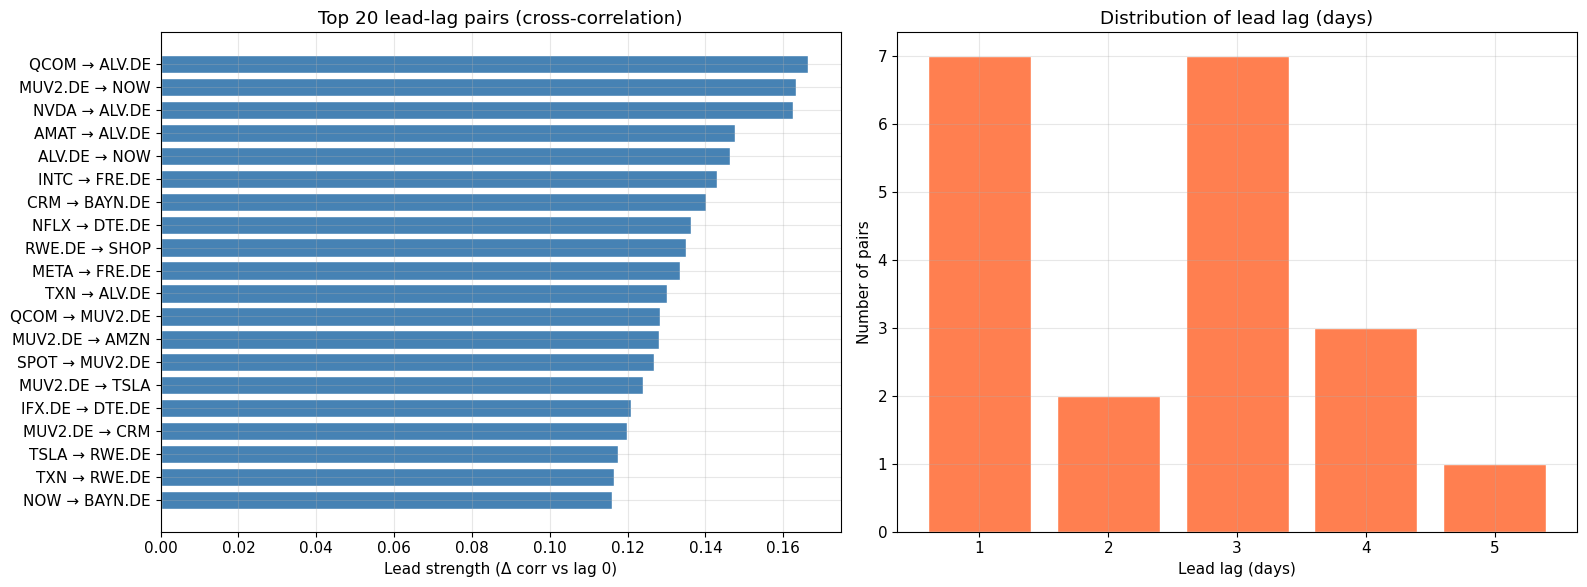

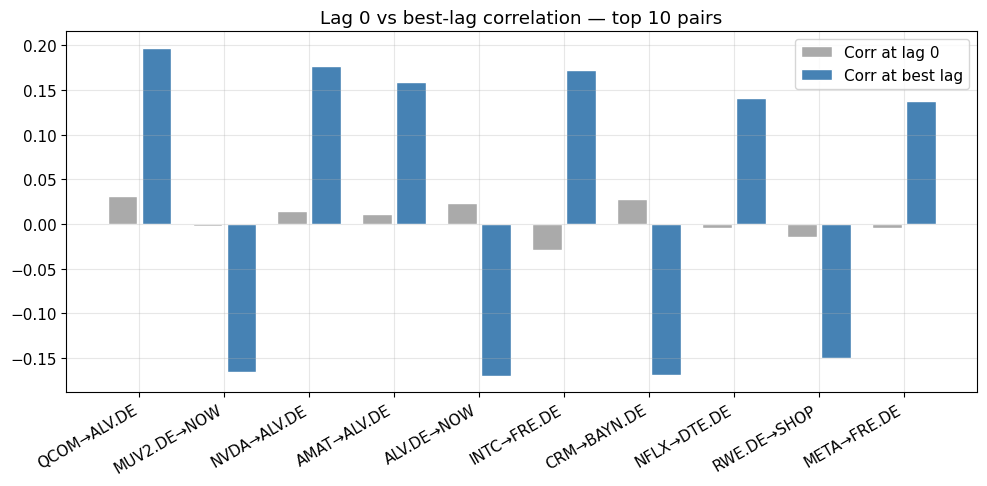

In [5]:
if not ll_df.empty:
    top20 = ll_df.head(20).copy()
    top20['pair'] = top20['leader'] + ' → ' + top20['follower']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Lead strength
    axes[0].barh(top20['pair'][::-1], top20['lead_strength'][::-1], color='steelblue', edgecolor='white')
    axes[0].set_xlabel('Lead strength (Δ corr vs lag 0)')
    axes[0].set_title('Top 20 lead-lag pairs (cross-correlation)')

    # Lag distribution
    lag_counts = top20['lag_days'].value_counts().sort_index()
    axes[1].bar(lag_counts.index, lag_counts.values, color='coral', edgecolor='white')
    axes[1].set_xlabel('Lead lag (days)')
    axes[1].set_ylabel('Number of pairs')
    axes[1].set_title('Distribution of lead lag (days)')
    axes[1].set_xticks(range(1, MAX_LAG_DAYS + 1))

    plt.tight_layout()
    plt.show()

    # Cross-corr at best lag vs lag 0
    fig, ax = plt.subplots(figsize=(10, 5))
    top10 = ll_df.head(10)
    x = np.arange(len(top10))
    ax.bar(x - 0.2, top10['corr_at_0'],   0.35, label='Corr at lag 0', color='#aaa', edgecolor='white')
    ax.bar(x + 0.2, top10['corr_at_lag'],  0.35, label='Corr at best lag', color='steelblue', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r['leader']}→{r['follower']}" for _, r in top10.iterrows()], rotation=30, ha='right')
    ax.set_title('Lag 0 vs best-lag correlation — top 10 pairs')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. Export

Updates `correlation_state.json` with full-universe lead-lag and Granger results.

In [6]:
existing = {}
if os.path.exists(OUTPUT_CORRELATION):
    with open(OUTPUT_CORRELATION, 'r') as f:
        existing = json.load(f)

existing.update({
    'leadlag_generated_at':   datetime.now().isoformat(),
    'leadlag_universe_size':  len(run_tickers),
    'lead_lag_pairs_full':    ll_results,
    'granger_results':        granger_results,
    'granger_significant':    [r for r in granger_results if r.get('granger_sig')],
})

with open(OUTPUT_CORRELATION, 'w', encoding='utf-8') as f:
    json.dump(existing, f, indent=2, default=str)

print(f'✅ Exported → {OUTPUT_CORRELATION}  ({os.path.getsize(OUTPUT_CORRELATION)/1024:.1f} KB)')
print(f'   {len(ll_results)} cross-corr pairs + {len(granger_results)} Granger tests added.')

✅ Exported → C:\Users\ahmty\Desktop\hedge-fund\research\notebooks\..\src\..\outputs\correlation_state.json  (389.1 KB)
   155 cross-corr pairs + 20 Granger tests added.
